In [1]:
import re
import os
import sys
import warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet, stopwords
from nltk import pos_tag
from spacy.lang.en.stop_words import STOP_WORDS as SPACY_STOP_WORDS

import gensim
from gensim import corpora
from gensim.models import LdaModel, CoherenceModel

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import Normalizer
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score

try:
    from sklearn.cluster import HDBSCAN
except Exception:
    HDBSCAN = None


def find_project_root(start=None):
    start = Path.cwd() if start is None else Path(start)

    for p in [start.resolve()] + list(start.resolve().parents):
        if (p / "csvs").exists() and (p / "markdown").exists():
            return p

    return start.resolve()


PROJECT_ROOT = find_project_root()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

try:
    import scripts.text_mining_utils as tmu
except Exception:
    tmu = None


CSVS_CHUNKED = PROJECT_ROOT / "csvs" / "chunked"
CHUNKS_ALL = CSVS_CHUNKED / "chunks_all.csv"

if not CHUNKS_ALL.exists():
    sandbox_chunks = Path("/mnt/data/chunks_all(5).csv")
    if sandbox_chunks.exists():
        CHUNKS_ALL = sandbox_chunks

PIPELINE_DIR = PROJECT_ROOT / "progress" / "topic_modelling" / "lda" / "sentiment"
OUT_DIR = PIPELINE_DIR / "output"
IMG_DIR = PIPELINE_DIR / "img"

OUT_DIR.mkdir(parents=True, exist_ok=True)
IMG_DIR.mkdir(parents=True, exist_ok=True)

warnings.filterwarnings("ignore")
sns.set(style="whitegrid")

NLTK_DATA_DIR = PROJECT_ROOT / "data" / "auto"
NLTK_DATA_DIR.mkdir(parents=True, exist_ok=True)
nltk.data.path.append(str(NLTK_DATA_DIR))

nltk_packages = [
    "punkt",
    "punkt_tab",
    "wordnet",
    "omw-1.4",
    "stopwords",
    "averaged_perceptron_tagger",
    "averaged_perceptron_tagger_eng",
]

for package in nltk_packages:
    try:
        nltk.download(package, download_dir=str(NLTK_DATA_DIR), quiet=True)
    except Exception as e:
        print(f"Warning: NLTK package not available: {package} ({e})")

print("Project root:", PROJECT_ROOT)
print("Input chunks file:", CHUNKS_ALL)
print("Pipeline folder:", PIPELINE_DIR)
print("Output folder:", OUT_DIR)
print("Utility module:", None if tmu is None else tmu.__name__)


Project root: /home/nsirim/Github/mscdsa/msc
Input chunks file: /home/nsirim/Github/mscdsa/msc/csvs/chunked/chunks_all.csv
Pipeline folder: /home/nsirim/Github/mscdsa/msc/progress/topic_modelling/lda/sentiment
Output folder: /home/nsirim/Github/mscdsa/msc/progress/topic_modelling/lda/sentiment/output
Utility module: scripts.text_mining_utils


In [2]:
# ==========================================
# Step 1: Loading data and preliminary filtering
# ==========================================

CORPUS_FILTER = "sentiment"

required_columns = {
    "doc_id",
    "corpus",
    "source_type",
    "heading_context",
    "chunk_text",
}


def safe_text(value):
    if pd.isna(value):
        return ""
    return str(value).strip()


def normalise_heading_text(heading):
    heading = safe_text(heading)
    heading = re.sub(r"\s+", " ", heading)
    heading = re.sub(r"^\d+(\.\d+)*\s+", "", heading)
    return heading.strip()


def build_original_heading_context_chunk_text(row):
    heading = normalise_heading_text(row["heading_context"])
    chunk_text = safe_text(row["chunk_text"])

    if heading and chunk_text.lower().startswith(heading.lower()):
        return chunk_text

    return f"{heading} {chunk_text}".strip()


def build_lda_source_text(row):
    heading = normalise_heading_text(row["heading_context"])
    chunk_text = safe_text(row["chunk_text"])

    if not heading:
        return chunk_text

    if chunk_text.lower().startswith(heading.lower()):
        return chunk_text

    heading_word_count = len(heading.split())

    if heading_word_count <= 12:
        return f"{heading}. {chunk_text}"

    return chunk_text


artifact_heading_pattern = re.compile(
    r"^(contents|table of contents|acknowledgements?|acronyms?|illustrations?|"
    r"bibliography|references|web sources|about the author|author|cover|"
    r"copyright|appendix|annex|figures?|tables?)$",
    re.IGNORECASE
)

artifact_chunk_pattern = re.compile(
    r"(table of contents|copyright|all rights reserved|isbn|bibliography|"
    r"references|web sources|cover photo|printed at|"
    r"directorate of communications)",
    re.IGNORECASE
)


def is_artifact_chunk(row):
    heading = normalise_heading_text(row["heading_context"])
    chunk_preview = safe_text(row["chunk_text"])[:500]

    if artifact_heading_pattern.match(heading):
        return True

    if artifact_chunk_pattern.search(chunk_preview):
        return True

    return False


try:
    print("Input file:", CHUNKS_ALL)

    df = pd.read_csv(CHUNKS_ALL, encoding="utf-8-sig")

    missing_columns = required_columns - set(df.columns)
    if missing_columns:
        raise ValueError(f"Missing required columns: {sorted(missing_columns)}")

    df = df[df["corpus"] == CORPUS_FILTER].copy()

    df["source_type"] = df["source_type"].fillna("").astype(str).str.strip().str.lower()
    df = df[df["source_type"].isin(["original", "synthetic"])].copy()

    df["heading_context"] = df["heading_context"].fillna("").astype(str)
    df["chunk_text"] = df["chunk_text"].fillna("").astype(str)

    df = df[df["chunk_text"] != "N/A"].copy()
    df = df[df["chunk_text"].str.strip() != ""].copy()

    rows_before_artifact_filter = len(df)
    df = df[~df.apply(is_artifact_chunk, axis=1)].copy()
    rows_after_artifact_filter = len(df)

    df["heading_context_chunk_text"] = df.apply(
        build_original_heading_context_chunk_text,
        axis=1
    )

    df["lda_source_text"] = df.apply(
        build_lda_source_text,
        axis=1
    )

    df = df[df["lda_source_text"].str.len() > 0].copy()

    print(f"Loaded sentiment chunks: {len(df)}")
    print(f"Rows removed by artifact filtering: {rows_before_artifact_filter - rows_after_artifact_filter}")
    print(f"Source types: {df['source_type'].nunique()}")
    print("\nChunks by source type:")
    print(df["source_type"].value_counts(dropna=False))

except FileNotFoundError:
    print("Error: chunks_all.csv not found.")
    print("Expected path:", CHUNKS_ALL)
    raise

except Exception as e:
    print(f"Error while loading chunks: {e}")
    raise


Input file: /home/nsirim/Github/mscdsa/msc/csvs/chunked/chunks_all.csv
Loaded sentiment chunks: 709
Rows removed by artifact filtering: 39
Source types: 2

Chunks by source type:
source_type
original     498
synthetic    211
Name: count, dtype: int64


In [3]:
# ==========================================
# Step 2: Corpus diagnostics before preprocessing
# ==========================================

diagnostic_rows = []

for source_type, source_df in df.groupby("source_type"):
    diagnostic_rows.append({
        "source_type": source_type,
        "documents": source_df["doc_id"].nunique(),
        "chunks": len(source_df),
        "mean_chunk_words": source_df["chunk_word_count"].mean()
        if "chunk_word_count" in source_df.columns else np.nan,
        "median_chunk_words": source_df["chunk_word_count"].median()
        if "chunk_word_count" in source_df.columns else np.nan,
        "min_chunk_words": source_df["chunk_word_count"].min()
        if "chunk_word_count" in source_df.columns else np.nan,
        "max_chunk_words": source_df["chunk_word_count"].max()
        if "chunk_word_count" in source_df.columns else np.nan,
    })

diagnostics_df = pd.DataFrame(diagnostic_rows).sort_values("source_type")

print("Corpus diagnostics:")
print(diagnostics_df.to_string(index=False))

diagnostics_path = OUT_DIR / "corpus_diagnostics_before_preprocessing.csv"
diagnostics_df.to_csv(diagnostics_path, index=False, encoding="utf-8-sig")

print(f"\nSaved: {diagnostics_path}")



Corpus diagnostics:
source_type  documents  chunks  mean_chunk_words  median_chunk_words  min_chunk_words  max_chunk_words
   original         17     498        256.493976               257.5               58             1214
  synthetic         53     211        313.061611               340.0               76              359

Saved: /home/nsirim/Github/mscdsa/msc/progress/topic_modelling/lda/sentiment/output/corpus_diagnostics_before_preprocessing.csv


In [4]:
# ==========================================
# Step 3: Stopwords definitions
# ==========================================

stop_words = set(SPACY_STOP_WORDS)

try:
    stop_words.update(set(stopwords.words("english")))
except Exception:
    pass

try:
    stop_words.update(set(stopwords.words("french")))
except Exception:
    pass

document_artifact_stopwords = [
    "pdf", "qxp", "page", "copyright", "reserved",
    "www", "http", "https", "com", "org",
    "figure", "table", "annex", "appendix", "footnote", "endnote",
    "isbn", "bibliography", "citation", "reference", "metadata", "docx",
    "executive summary", "draft", "matrix", "blueprint", "snapshot",
    "chart", "brochure", "fig"
]

legal_structure_stopwords = [
    "section", "chapter", "part", "title", "article", "clause",
    "paragraph", "subparagraph", "schedule", "exhibit", "supplement",
    "addendum", "preamble", "recital", "report",
    "chapitre", "partie", "titre", "paragraphe", "alinea",
    "annexe", "appendice", "expos", "des", "motifs",
    "disposition"
]

legal_boilerplate_stopwords = [
    "coppa", "ferpa", "enact", "bit",
    "herein", "therein", "thereof", "whereof", "hereby",
    "whereby", "hereinafter", "thereafter", "aforementioned",
    "foregoing", "henceforth", "whereto", "whereupon",
    "notwithstanding", "pursuant", "thereto", "thereunder", "hereto",
    "susmentionn", "prcit", "nonobstant", "par drogation",
    "en", "consquence", "eu", "gard", "aux fins",
    "selon", "conformment", "outre", "ladite", "ledit", "dune"
]

policy_action_stopwords = [
    "shall", "must", "may", "might", "could", "would", "should", "will",
    "require", "requires", "required",
    "ensure", "ensures",
    "seek", "seeks", "seeking",
    "establish", "establishes",
    "promote", "promotes", "promoting",
    "maintain", "respect",
    "doit", "devrait", "pourrait", "vouloir",
    "exiger", "requis", "assurer", "garantir",
    "rechercher", "tablir", "promouvoir",
    "maintenir", "respecter"
]

policy_connector_stopwords = [
    "various", "several", "multiple", "certain", "relevant", "appropriate",
    "regarding", "concerning", "involving", "accordance",
    "relate", "relates", "relating",
    "furthermore", "moreover", "therefore", "thus", "hence",
    "however", "although", "including", "etc", "etcetera",
    "concernant", "divers", "plusieurs", "particulier",
    "certain", "aussi", "de plus", "en outre",
    "par consquent", "donc", "ainsi", "cependant",
    "bien que", "notamment", "entre autres", "comme",
    "toute", "tous", "cette", "plus", "leurs"
]

geo_institutional_stopwords = [
    "ireland", "irish", "france", "french", "usa", "america",
    "australia", "australian",
    "country", "nation", "national", "state",
    "government", "federal", "ministry", "department",
    "gouvernement", "ministre", "dtat", "republic",
    "pittsburg", "antioch", "medina", "winterset",
    "sara", "washington", "california", "massachusetts",
    "oregon", "sweden", "unified", "district",
    "commonwealth", "nsw",
    "europe", "european", "union", "council"
]

tech_ai_stopwords = [
    "artificial", "intelligence",
    "ai", "ia", "lia", "dia",
    "genai", "generative",
    "model", "models", "llm",
    "algorithm", "algorithms",
    "machine", "learning",
    "data", "dataset", "datasets",
    "digital", "numrique",
    "computer", "software", "hardware",
    "technology", "technological",
    "platform", "online", "internet", "web", "electronic",
    "tool", "tools", "system", "systems", "device", "application", "app", "service",
    "broadband", "connectivity", "vendor", "player", "enterprise",
    "artificielle", "gen", "generatif",
    "modle", "modles",
    "apprentissage", "donn",
    "ordinateur", "logiciel", "matriel",
    "technologie", "plateforme", "ligne",
    "ectronique", "outil", "systme", "dispositif",
    "générative", "intelligent",
    "edge", "gpt", "openai", "microsoft", "google",
    "amazon", "meta", "ibm", "nvidia", "intel",
    "gemini", "deepseek", "anthropic", "claude",
    "embedding", "transformer", "natural language",
    "climate change", "ieee", "architecture",
    "chatgtp", "copilot", "kwyk", "technologies",
    "new", "work", "law", "right",
    "services", "based", "case", "support", "human",
    "generated", "related"
]

education_stopwords = [
    "school", "education", "educational",
    "pupil", "classroom", "learning",
    "teacher", "teachers", "schools",
    "student", "students",
    "post", "primary", "technical",
    "cole", "educatif", "enseignant", "enseignats", "enseignants",
    "professeur", "programme",
    "apprentissage", "enseignement", "formation",
    "établissement", "éducation", "école",
    "élève", "élèves",
    "covid", "showcase", "deliverable"
]

org_name_stopwords = [
    "adam", "mary", "jensen", "abraham", "lincoln",
    "knight", "kim", "guez",
    "oecd", "cbs", "webwise", "cosn", "dlf",
    "scoilnet", "deap", "dne", "men",
    "parliament", "commissioner", "public sector",
    "cipa", "protection act", "oide", "tie", "cpd",
    "coe", "un", "unesco", "unicef", "qqi"
]

generic_noise_stopwords = [
    "feel", "like", "everybody", "actually",
    "kid", "employee", "min", "box", "loop",
    "black", "asset", "typical", "era",
    "acquire", "behavioral", "behavioural",
    "revolution", "emission", "talent",
    "billion", "count", "witness", "operator",
    "interim", "resourced", "resourcing",
    "round", "support work", "dashboard",
    "ela", "estonia", "pisa", "perspectives",
    "final", "total", "describe", "visit",
    "original", "sample", "low",
    "answer", "ask", "efficacy",
    "deepen", "enhance",
    "author", "researcher", "mission", "personnel",
    "palo", "alto", "card",
    "use", "lot", "enable", "constituent",
    "session", "policy", "document",
    "member", "organisation", "goal",
    "long term", "desirable", "young",
    "ite", "aied", "australasian",
    "perplexed", "guidetoaiinschools", "nenufsd",
    "dent", "fee", "want", "prof", "stu",
    "public", "people", "different", "important",
    "available", "specific", "level", "time"
]

sentiment_corpus_stopwords = [
    "sentiment", "synthetic", "source",
    "press", "release",
    "respondent", "respondents",
    "participant", "participants",
    "survey", "questionnaire", "interview",
    "response", "responses",
    "accessed", "amp",
    "preferred", "continued", "depends",
    "clear", "careful", "practical",
    "approach"
]

date_time_stopwords = [
    "july", "april", "august", "march", "november", "december"
]

corpus_checked_sentiment_stopwords = [
    "youth", "worker", "sector", "young",
    "veronica", "stefan", "partnership",
    "printed", "strasbourg", "cedex", "shutterstock",
    "publishing", "cover", "photo", "directorate", "communications",
    "stakeholder", "stakeholders",
    "initiative", "initiatives",
    "development", "develop",
    "include", "provide", "need", "make", "think",
    "issue", "area", "process", "practice",
    "challenge", "opportunity", "benefit", "risk", "impact",
    "discussion", "debate", "change", "future", "way", "role",
    "view", "good", "bad", "better", "best", "thing",
    "parent", "parents", "children", "child",
    "educator", "educators", "learner", "learners",
    "concern", "guidance", "literacy", "professional",
    "research", "study", "teach", "train", "understand"
]

post_cleaning_generic_stopwords = [
    "être", "avoir", "faire", "peut",
    "tout", "tous", "toute", "toutes",
    "autre", "autres",
    "encore", "déjà", "non", "sans",
    "dont", "cela", "même", "mme",
    "très", "moins", "plus", "souvent",
    "cas", "type", "manière", "fonction", "partir",
    "exemple", "question", "réponse", "résultat",
    "objectif", "contenu", "texte", "image"
]

fragment_stopwords = [
    "ing", "tion", "ment", "ness", "ly",
    "able", "ive", "ent", "ant",
    "ence", "ance",
    "ali", "gue", "rod", "rodr",
    "educa", "evi", "al", "ons", "onal", "effec",
    "con", "consulta", "prac"
]

custom_stopword_categories = [
    document_artifact_stopwords,
    legal_structure_stopwords,
    legal_boilerplate_stopwords,
    policy_action_stopwords,
    policy_connector_stopwords,
    geo_institutional_stopwords,
    tech_ai_stopwords,
    education_stopwords,
    org_name_stopwords,
    generic_noise_stopwords,
    sentiment_corpus_stopwords,
    date_time_stopwords,
    corpus_checked_sentiment_stopwords,
    post_cleaning_generic_stopwords,
    fragment_stopwords,
]

custom_stopwords = set()

for category in custom_stopword_categories:
    custom_stopwords.update(category)

stop_words.update(custom_stopwords)

print(f"Stopwords loaded: {len(stop_words)}")


Stopwords loaded: 1119


In [5]:
# ==========================================
# Step 4: Cleaning and preprocessing helpers
# ==========================================

lemmatizer = WordNetLemmatizer()

extra_french_stopwords = {
    "la", "le", "les", "de", "un", "une", "des", "du", "au", "aux",
    "ce", "cet", "cette", "ces", "je", "me", "te", "se", "ne",
    "que", "qui", "quoi", "dont", "dans", "pour", "par", "sur",
    "avec", "sans", "plus", "moins", "tres", "très", "pas",
    "tout", "tous", "toute", "toutes", "autre", "autres",
    "cela", "meme", "même", "encore"
}

stop_words.update(extra_french_stopwords)


def get_wordnet_pos(treebank_tag):
    if treebank_tag.startswith("J"):
        return wordnet.ADJ
    if treebank_tag.startswith("V"):
        return wordnet.VERB
    if treebank_tag.startswith("N"):
        return wordnet.NOUN
    if treebank_tag.startswith("R"):
        return wordnet.ADV
    return wordnet.NOUN


def has_non_ascii(token):
    return any(ord(char) > 127 for char in token)


def clean_text(text):
    text = str(text).lower()

    text = text.replace("’", "'").replace("‘", "'").replace("`", "'")
    text = text.replace("guillemetleft", " ")
    text = text.replace("guillemetright", " ")

    ocr_fixes = {
        r"\blve\b": "élève",
        r"\blves\b": "élèves",
        r"\bducation\b": "éducation",
        r"\b1ducation\b": "éducation",
        r"\bducatif\b": "éducatif",
        r"\bducative\b": "éducative",
        r"\bducatifs\b": "éducatifs",
        r"\bducatives\b": "éducatives",
        r"\btablissement\b": "établissement",
        r"\btablissements\b": "établissements",
        r"\bvaluation\b": "évaluation",
        r"\bvaluer\b": "évaluer",
        r"\btrs\b": "très",
        r"\blment\b": "élément",
        r"\blments\b": "éléments",
    }

    for pattern, replacement in ocr_fixes.items():
        text = re.sub(pattern, replacement, text)

    french_contractions = {
        r"\bl'": "la ",
        r"\bd'": "de ",
        r"\bc'": "ce ",
        r"\bj'": "je ",
        r"\bm'": "me ",
        r"\bt'": "te ",
        r"\bs'": "se ",
        r"\bn'": "ne ",
        r"\bqu'": "que ",
        r"\blorsqu'": "lorsque ",
        r"\bpuisqu'": "puisque ",
        r"\bquoiqu'": "quoique ",
        r"\bjusqu'": "jusque ",
        r"\baujourd'": "aujourd ",
    }

    for pattern, replacement in french_contractions.items():
        text = re.sub(pattern, replacement, text)

    text = re.sub(r"\S*@\S*\s?", " ", text)
    text = re.sub(r"http\S+|www\S+|https\S+", " ", text)
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"\[\d+\]", " ", text)
    text = re.sub(r"\(\s*see\s+[^\)]+\)", " ", text)
    text = re.sub(r"footnote\s*\d+", " ", text)

    text = re.sub(r"\b\d+[\w-]*\b", " ", text)
    text = re.sub(r"\b(amp|lt|gt|quot|nbsp)\b", " ", text)

    text = re.sub(r"[^a-zàâäéèêëïîôùûüÿçæœ\s-]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    tokens = text.split()

    cleaned_tokens = []

    for token in tokens:
        token = token.strip("-")

        if not token:
            continue

        if len(token) <= 2:
            continue

        if re.fullmatch(r"[a-zàâäéèêëïîôùûüÿçæœ]-[a-zàâäéèêëïîôùûüÿçæœ]", token):
            continue

        cleaned_tokens.append(token)

    return cleaned_tokens


def remove_stopwords(tokens):
    filtered_tokens = []

    for token in tokens:
        token = token.strip("_-")

        if not token:
            continue

        parts = token.split("_")

        if len(token) <= 2:
            continue

        if token in stop_words:
            continue

        if all(part in stop_words for part in parts):
            continue

        if any(len(part) <= 2 for part in parts):
            continue

        filtered_tokens.append(token)

    return filtered_tokens


def simple_lemma(token):
    if "_" in token:
        return token

    if has_non_ascii(token):
        return token

    if len(token) > 5 and token.endswith("ies"):
        return token[:-3] + "y"

    if len(token) > 5 and token.endswith("ing"):
        return token[:-3]

    if len(token) > 4 and token.endswith("ed"):
        return token[:-2]

    if len(token) > 4 and token.endswith("s") and not token.endswith("ss"):
        return token[:-1]

    return token


def lemmatize_tokens(tokens):
    if not tokens:
        return []

    try:
        pos_tags = pos_tag(tokens)

        return [
            token
            if "_" in token or has_non_ascii(token)
            else lemmatizer.lemmatize(token, get_wordnet_pos(pos))
            for token, pos in pos_tags
        ]

    except Exception:
        return [
            simple_lemma(token)
            for token in tokens
        ]


def preprocess_without_phrases(text):
    tokens = clean_text(text)
    tokens = remove_stopwords(tokens)
    tokens = lemmatize_tokens(tokens)
    tokens = remove_stopwords(tokens)

    return tokens


def preprocess_text(text):
    tokens = clean_text(text)
    tokens = remove_stopwords(tokens)
    tokens = lemmatize_tokens(tokens)
    tokens = remove_stopwords(tokens)

    tokens = [
        token
        for token in tokens
        if "_" not in token
    ]

    return tokens

In [6]:
# ==========================================
# Step 5: Apply unigram-only preprocessing
# ==========================================

MIN_PROCESSED_TOKENS = 30

df["heading_context_chunk_text_processed_tokens"] = (
    df["lda_source_text"]
    .apply(preprocess_text)
)

df["heading_context_chunk_text_processed"] = (
    df["heading_context_chunk_text_processed_tokens"]
    .apply(lambda tokens: " ".join(tokens))
)

df["processed_token_count"] = (
    df["heading_context_chunk_text_processed_tokens"]
    .apply(len)
)

before_length_filter = len(df)

df = df[df["processed_token_count"] >= MIN_PROCESSED_TOKENS].copy()

after_length_filter = len(df)

before_dedup = len(df)

df = df.drop_duplicates(
    subset=["source_type", "heading_context_chunk_text_processed"]
).copy()

after_dedup = len(df)

print(f"Rows before token-length filter: {before_length_filter}")
print(f"Rows after token-length filter: {after_length_filter}")
print(f"Rows removed by exact duplicate filtering: {before_dedup - after_dedup}")
print(f"Final rows after unigram-only preprocessing: {len(df)}")

print("\nProcessed token counts:")
print(df["processed_token_count"].describe())

print("\nRows by source type after preprocessing:")
print(df["source_type"].value_counts(dropna=False))


Rows before token-length filter: 709
Rows after token-length filter: 677
Rows removed by exact duplicate filtering: 30
Final rows after unigram-only preprocessing: 647

Processed token counts:
count    647.000000
mean      84.826893
std       32.698184
min       30.000000
25%       62.000000
50%       84.000000
75%      103.000000
max      336.000000
Name: processed_token_count, dtype: float64

Rows by source type after preprocessing:
source_type
original     437
synthetic    210
Name: count, dtype: int64


In [7]:
# ==========================================
# Step 6: Create global dictionary and corpus
# ==========================================

texts = df["heading_context_chunk_text_processed_tokens"].tolist()

dictionary = corpora.Dictionary(texts)

dictionary.filter_extremes(
    no_below=10,
    no_above=0.20,
    keep_n=2500
)

doc_term_matrix = [
    dictionary.doc2bow(tokens)
    for tokens in texts
]

valid_bow_mask = [
    len(bow) > 0
    for bow in doc_term_matrix
]

df = df[valid_bow_mask].copy()
texts = df["heading_context_chunk_text_processed_tokens"].tolist()

doc_term_matrix = [
    dictionary.doc2bow(tokens)
    for tokens in texts
]

print(f"Dictionary size: {len(dictionary)}")
print(f"Documents in global corpus: {len(doc_term_matrix)}")
print(f"Average tokens per document: {np.mean([len(t) for t in texts]):.2f}")

print("\nDocuments by source type in final global corpus:")
print(df["source_type"].value_counts(dropna=False))


Dictionary size: 970
Documents in global corpus: 647
Average tokens per document: 84.83

Documents by source type in final global corpus:
source_type
original     437
synthetic    210
Name: count, dtype: int64


In [8]:
# ==========================================
# Step 7: Post-preprocessing corpus diagnostics
# ==========================================

token_counts = Counter()

for tokens in texts:
    token_counts.update(tokens)

top_tokens_df = pd.DataFrame(
    token_counts.most_common(100),
    columns=["token", "count"]
)

print("Top 50 tokens after preprocessing:")
print(top_tokens_df.head(50).to_string(index=False))

top_tokens_path = OUT_DIR / "top_tokens_after_preprocessing.csv"
top_tokens_df.to_csv(top_tokens_path, index=False, encoding="utf-8-sig")

print(f"\nSaved: {top_tokens_path}")

source_type_token_rows = []

for source_type, source_df in df.groupby("source_type"):
    source_tokens = [
        token
        for tokens in source_df["heading_context_chunk_text_processed_tokens"]
        for token in tokens
    ]

    source_counter = Counter(source_tokens)

    for token, count in source_counter.most_common(30):
        source_type_token_rows.append({
            "source_type": source_type,
            "token": token,
            "count": count
        })

source_type_top_tokens_df = pd.DataFrame(source_type_token_rows)

source_type_top_tokens_path = OUT_DIR / "top_tokens_by_source_type_after_preprocessing.csv"
source_type_top_tokens_df.to_csv(source_type_top_tokens_path, index=False, encoding="utf-8-sig")

print(f"Saved: {source_type_top_tokens_path}")


Top 50 tokens after preprocessing:
         token  count
    confidence    470
     oversight    407
implementation    394
       ethical    296
         skill    250
          know    240
     potential    235
         group    220
       example    211
        social    205
         focus    201
       privacy    188
    assessment    184
    experience    183
    perception    178
   responsible    176
   information    173
         point    171
          high    167
        access    163
          help    161
          fear    150
       project    147
        engage    147
      positive    146
        follow    144
      analysis    144
       pathway    144
     knowledge    142
         ethic    136
         staff    136
       content    132
          task    132
      negative    131
      training    126
        number    125
   implication    124
       comment    124
     framework    123
      resource    123
          idea    123
      academic    122
        design    1

In [9]:
# ==========================================
# Step 8: LDA helper functions
# ==========================================

def topic_diversity(model, topn=15):
    topic_words = []

    for topic_id in range(model.num_topics):
        topic_words.extend([
            word
            for word, weight in model.show_topic(topic_id, topn=topn)
        ])

    if len(topic_words) == 0:
        return 0

    return len(set(topic_words)) / len(topic_words)


LDA_PASSES = 6
LDA_ITERATIONS = 100


def fit_lda_grid(texts, dictionary, doc_term_matrix, topic_range):
    coherence_scores = []
    diversity_scores = []
    lda_models = []

    for num_topics in topic_range:
        lda_model = LdaModel(
            corpus=doc_term_matrix,
            id2word=dictionary,
            num_topics=num_topics,
            chunksize=1000,
            passes=LDA_PASSES,
            iterations=LDA_ITERATIONS,
            random_state=43,
            update_every=1,
            alpha="auto",
            eta="auto",
            minimum_probability=0.01,
            eval_every=None
        )

        coherence_model = CoherenceModel(
            model=lda_model,
            texts=texts,
            dictionary=dictionary,
            coherence="c_v",
            topn=10,
            processes=1
        )

        coherence = coherence_model.get_coherence()
        diversity = topic_diversity(lda_model, topn=15)

        lda_models.append(lda_model)
        coherence_scores.append(coherence)
        diversity_scores.append(diversity)

        print(
            f"Topics: {num_topics} | "
            f"Coherence: {coherence:.4f} | "
            f"Diversity: {diversity:.4f}"
        )

    return {
        "topic_range": topic_range,
        "coherence_scores": coherence_scores,
        "diversity_scores": diversity_scores,
        "lda_models": lda_models
    }


def select_best_model(grid_result, min_diversity=0.80):
    coherence_scores = grid_result["coherence_scores"]
    diversity_scores = grid_result["diversity_scores"]

    valid_indices = [
        i
        for i, diversity in enumerate(diversity_scores)
        if diversity >= min_diversity
    ]

    if len(valid_indices) > 0:
        best_idx = max(
            valid_indices,
            key=lambda i: coherence_scores[i]
        )
    else:
        best_idx = int(np.argmax(coherence_scores))

    return best_idx


In [10]:
# ==========================================
# Step 9: Determine global optimal topics
# ==========================================

topic_range = [3, 4, 5, 6, 7, 8, 9, 10]

print("Running global LDA grid search...")

global_grid = fit_lda_grid(
    texts=texts,
    dictionary=dictionary,
    doc_term_matrix=doc_term_matrix,
    topic_range=topic_range
)

best_idx = select_best_model(global_grid, min_diversity=0.80)

best_num_topics = topic_range[best_idx]
best_coherence = global_grid["coherence_scores"][best_idx]
best_diversity = global_grid["diversity_scores"][best_idx]
best_lda_model = global_grid["lda_models"][best_idx]

print("\nBest global model:")
print(f"Best number of topics: {best_num_topics}")
print(f"Best coherence score: {best_coherence:.4f}")
print(f"Best topic diversity: {best_diversity:.4f}")


Running global LDA grid search...
Topics: 3 | Coherence: 0.5343 | Diversity: 0.9111
Topics: 4 | Coherence: 0.6130 | Diversity: 0.9000
Topics: 5 | Coherence: 0.6214 | Diversity: 0.9333
Topics: 6 | Coherence: 0.5924 | Diversity: 0.8333
Topics: 7 | Coherence: 0.5995 | Diversity: 0.8095
Topics: 8 | Coherence: 0.6185 | Diversity: 0.7917
Topics: 9 | Coherence: 0.6066 | Diversity: 0.7926
Topics: 10 | Coherence: 0.6090 | Diversity: 0.7800

Best global model:
Best number of topics: 5
Best coherence score: 0.6214
Best topic diversity: 0.9333


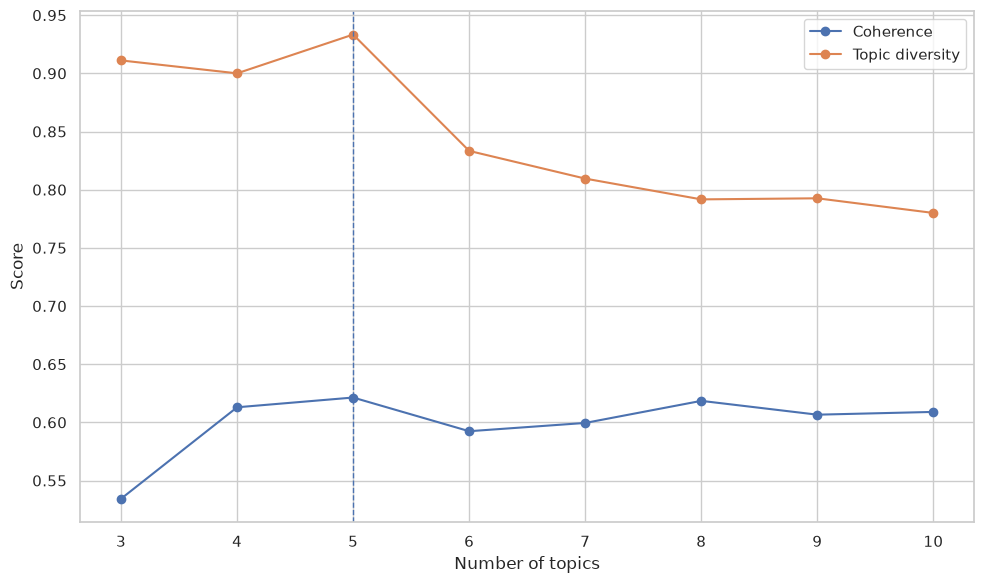

Saved: /home/nsirim/Github/mscdsa/msc/progress/topic_modelling/lda/sentiment/img/lda_global_coherence_diversity.png


In [11]:
# ==========================================
# Step 10: Plot global coherence and diversity scores
# ==========================================

global_scores_df = pd.DataFrame({
    "num_topics": topic_range,
    "coherence_score": global_grid["coherence_scores"],
    "topic_diversity": global_grid["diversity_scores"]
})

plt.figure(figsize=(10, 6))

plt.plot(
    global_scores_df["num_topics"],
    global_scores_df["coherence_score"],
    marker="o",
    label="Coherence"
)

plt.plot(
    global_scores_df["num_topics"],
    global_scores_df["topic_diversity"],
    marker="o",
    label="Topic diversity"
)

plt.axvline(
    best_num_topics,
    linestyle="--",
    linewidth=1
)

plt.xlabel("Number of topics")
plt.ylabel("Score")
# plt.title("Global LDA coherence and diversity")
plt.legend()
plt.tight_layout()

save_path = IMG_DIR / "lda_global_coherence_diversity.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight")

plt.show()
plt.close()

global_scores_csv_path = OUT_DIR / "lda_global_coherence_diversity.csv"

global_scores_df.to_csv(
    global_scores_csv_path,
    index=False,
    encoding="utf-8-sig"
)

print(f"Saved: {save_path}")


In [12]:
# ==========================================
# Step 11: Display best global topics
# ==========================================

num_words = 15
global_topic_rows = []

print(f"Best number of topics: {best_num_topics}")
print(f"Best coherence score: {best_coherence:.4f}")
print(f"Best topic diversity: {best_diversity:.4f}")

for topic_id, terms in best_lda_model.show_topics(
    num_topics=best_num_topics,
    num_words=num_words,
    formatted=False
):
    topic_terms = [
        term
        for term, weight in terms
    ]

    topic_weight_pairs = [
        f"{term} ({weight:.4f})"
        for term, weight in terms
    ]

    global_topic_rows.append({
        "scope_label": "global_sentiment",
        "scope_type": "sentiment_corpus_input",
        "best_num_topics": best_num_topics,
        "best_coherence": best_coherence,
        "best_diversity": best_diversity,
        "topic_id": topic_id,
        "topic_terms": ", ".join(topic_terms),
        "topic_terms_with_weights": ", ".join(topic_weight_pairs)
    })

    print("\n" + "-" * 80)
    print(f"Topic {topic_id}")
    print(", ".join(topic_weight_pairs))

global_topics_df = pd.DataFrame(global_topic_rows)

global_topics_csv_path = OUT_DIR / "lda_best_global_sentiment_topics.csv"

global_topics_df.to_csv(
    global_topics_csv_path,
    index=False,
    encoding="utf-8-sig"
)

print(f"\nSaved: {global_topics_csv_path}")


Best number of topics: 5
Best coherence score: 0.6214
Best topic diversity: 0.9333

--------------------------------------------------------------------------------
Topic 0
fear (0.0215), high (0.0206), score (0.0117), perception (0.0117), discourse (0.0114), analysis (0.0114), optimism (0.0104), age (0.0096), limerick (0.0087), narrative (0.0085), employment (0.0084), confidence (0.0083), hope (0.0081), dublin (0.0080), cork (0.0077)

--------------------------------------------------------------------------------
Topic 1
group (0.0119), ethic (0.0110), staff (0.0100), governance (0.0070), bias (0.0062), engage (0.0062), framework (0.0051), address (0.0051), company (0.0049), project (0.0048), design (0.0048), lead (0.0047), space (0.0046), follow (0.0045), institution (0.0045)

--------------------------------------------------------------------------------
Topic 2
pathway (0.0195), agree (0.0146), mooc (0.0110), knowledge (0.0107), experience (0.0105), perception (0.0091), number (0

In [13]:
# ==========================================
# Step 12: Determine optimal topics by source type
# ==========================================

source_type_results = {}

source_type_topic_range = [2, 3, 4, 5, 6, 7, 8, 9, 10]
min_source_type_documents = 30

source_types = [
    source_type
    for source_type in sorted(df["source_type"].dropna().unique())
    if source_type in ["original", "synthetic"]
]

for source_type in source_types:
    print("\n" + "=" * 100)
    print(f"Source type: {source_type}")

    source_df = df[df["source_type"] == source_type].copy()

    if len(source_df) < min_source_type_documents:
        print(f"Skipping {source_type}: {len(source_df)} documents")
        continue

    source_texts = source_df["heading_context_chunk_text_processed_tokens"].tolist()

    source_texts = [
        tokens
        for tokens in source_texts
        if len(tokens) >= MIN_PROCESSED_TOKENS
    ]

    if len(source_texts) < min_source_type_documents:
        print(f"Skipping {source_type}: insufficient token-valid documents")
        continue

    source_dictionary = corpora.Dictionary(source_texts)

    if len(source_texts) >= 500:
        no_below_value = 5
    elif len(source_texts) >= 200:
        no_below_value = 3
    else:
        no_below_value = 2

    source_dictionary.filter_extremes(
        no_below=no_below_value,
        no_above=0.30,
        keep_n=2000
    )

    source_doc_term_matrix = [
        source_dictionary.doc2bow(tokens)
        for tokens in source_texts
    ]

    valid_bow_mask = [
        len(bow) > 0
        for bow in source_doc_term_matrix
    ]

    source_texts = [
        tokens
        for tokens, valid in zip(source_texts, valid_bow_mask)
        if valid
    ]

    source_doc_term_matrix = [
        bow
        for bow in source_doc_term_matrix
        if len(bow) > 0
    ]

    if len(source_doc_term_matrix) < min_source_type_documents:
        print(f"Skipping {source_type}: insufficient valid documents after dictionary filtering")
        continue

    max_topics = min(max(source_type_topic_range), len(source_doc_term_matrix) - 1)

    topic_range_source_type = [
        topic
        for topic in source_type_topic_range
        if topic <= max_topics
    ]

    print(f"Documents: {len(source_doc_term_matrix)}")
    print(f"Dictionary size: {len(source_dictionary)}")
    print(f"Adaptive no_below used: {no_below_value}")

    source_grid = fit_lda_grid(
        texts=source_texts,
        dictionary=source_dictionary,
        doc_term_matrix=source_doc_term_matrix,
        topic_range=topic_range_source_type
    )

    min_diversity_source_type = 0.65 if source_type == "synthetic" else 0.80

    best_idx_source_type = select_best_model(
        source_grid,
        min_diversity=min_diversity_source_type
    )

    source_type_results[source_type] = {
        "source_type": source_type,
        "dictionary": source_dictionary,
        "texts": source_texts,
        "doc_term_matrix": source_doc_term_matrix,
        "topic_range": topic_range_source_type,
        "coherence_scores": source_grid["coherence_scores"],
        "diversity_scores": source_grid["diversity_scores"],
        "best_num_topics": topic_range_source_type[best_idx_source_type],
        "best_coherence": source_grid["coherence_scores"][best_idx_source_type],
        "best_diversity": source_grid["diversity_scores"][best_idx_source_type],
        "best_model": source_grid["lda_models"][best_idx_source_type],
        "document_count": len(source_doc_term_matrix),
        "dictionary_size": len(source_dictionary),
        "no_below_value": no_below_value,
        "min_diversity_used": min_diversity_source_type
    }

    print("\nBest source type model:")
    print(f"Best topics: {source_type_results[source_type]['best_num_topics']}")
    print(f"Best coherence: {source_type_results[source_type]['best_coherence']:.4f}")
    print(f"Best diversity: {source_type_results[source_type]['best_diversity']:.4f}")
    print(f"Minimum diversity used: {min_diversity_source_type:.2f}")

print(f"\nSource types modelled: {len(source_type_results)}")



Source type: original
Documents: 437
Dictionary size: 2000
Adaptive no_below used: 3
Topics: 2 | Coherence: 0.2776 | Diversity: 0.9000
Topics: 3 | Coherence: 0.4610 | Diversity: 0.9333
Topics: 4 | Coherence: 0.4166 | Diversity: 0.8667
Topics: 5 | Coherence: 0.3875 | Diversity: 0.8267
Topics: 6 | Coherence: 0.4123 | Diversity: 0.8111
Topics: 7 | Coherence: 0.4500 | Diversity: 0.7714
Topics: 8 | Coherence: 0.4101 | Diversity: 0.7167
Topics: 9 | Coherence: 0.4592 | Diversity: 0.7481
Topics: 10 | Coherence: 0.4415 | Diversity: 0.7467

Best source type model:
Best topics: 3
Best coherence: 0.4610
Best diversity: 0.9333
Minimum diversity used: 0.80

Source type: synthetic
Documents: 210
Dictionary size: 1381
Adaptive no_below used: 3
Topics: 2 | Coherence: 0.5215 | Diversity: 0.9000
Topics: 3 | Coherence: 0.4039 | Diversity: 0.8000
Topics: 4 | Coherence: 0.5321 | Diversity: 0.7333
Topics: 5 | Coherence: 0.4396 | Diversity: 0.6533
Topics: 6 | Coherence: 0.4570 | Diversity: 0.6444
Topics: 7 |

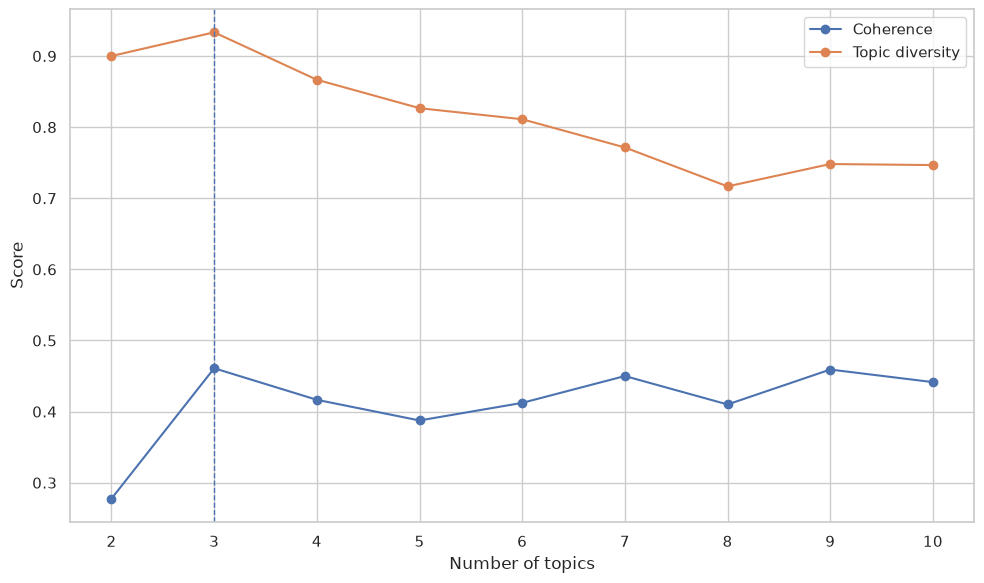

Saved: /home/nsirim/Github/mscdsa/msc/progress/topic_modelling/lda/sentiment/img/lda_source_type_coherence_diversity_original.png


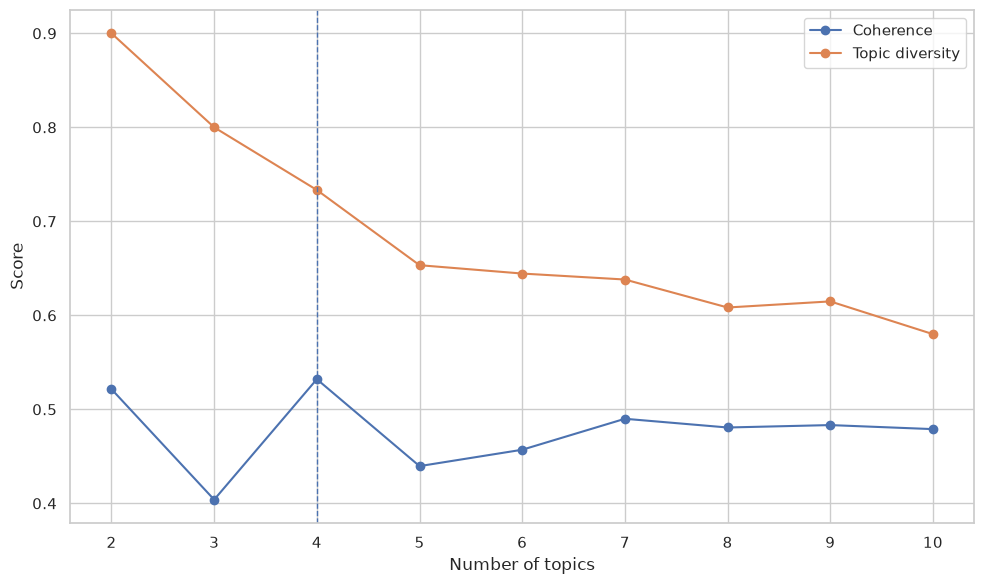

Saved: /home/nsirim/Github/mscdsa/msc/progress/topic_modelling/lda/sentiment/img/lda_source_type_coherence_diversity_synthetic.png
Saved: /home/nsirim/Github/mscdsa/msc/progress/topic_modelling/lda/sentiment/output/lda_source_type_coherence_diversity.csv


In [14]:
# ==========================================
# Step 13: Plot coherence and diversity by source type
# ==========================================

source_type_score_rows = []

for source_type, result in source_type_results.items():
    source_type_scores_df = pd.DataFrame({
        "source_type": source_type,
        "num_topics": result["topic_range"],
        "coherence_score": result["coherence_scores"],
        "topic_diversity": result["diversity_scores"]
    })

    source_type_score_rows.append(source_type_scores_df)

    plt.figure(figsize=(10, 6))

    plt.plot(
        source_type_scores_df["num_topics"],
        source_type_scores_df["coherence_score"],
        marker="o",
        label="Coherence"
    )

    plt.plot(
        source_type_scores_df["num_topics"],
        source_type_scores_df["topic_diversity"],
        marker="o",
        label="Topic diversity"
    )

    plt.axvline(
        result["best_num_topics"],
        linestyle="--",
        linewidth=1
    )

    plt.xlabel("Number of topics")
    plt.ylabel("Score")
    # plt.title(f"LDA coherence and diversity: {source_type}")
    plt.legend()
    plt.tight_layout()

    safe_source_type = str(source_type).replace(" ", "_").lower()
    save_path = IMG_DIR / f"lda_source_type_coherence_diversity_{safe_source_type}.png"

    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

    print(f"Saved: {save_path}")

source_type_scores_all_df = pd.concat(
    source_type_score_rows,
    ignore_index=True
)

source_type_scores_csv_path = OUT_DIR / "lda_source_type_coherence_diversity.csv"

source_type_scores_all_df.to_csv(
    source_type_scores_csv_path,
    index=False,
    encoding="utf-8-sig"
)

print(f"Saved: {source_type_scores_csv_path}")


In [15]:
# ==========================================
# Step 14: Display best topics by source type
# ==========================================

source_type_topic_rows = []
num_words = 15

for source_type, result in source_type_results.items():
    best_model_source_type = result["best_model"]
    best_num_topics_source_type = result["best_num_topics"]
    best_coherence_source_type = result["best_coherence"]
    best_diversity_source_type = result["best_diversity"]

    print("\n" + "=" * 100)
    print(f"Source type: {source_type}")
    print(f"Documents: {result['document_count']}")
    print(f"Dictionary size: {result['dictionary_size']}")
    print(f"Adaptive no_below: {result['no_below_value']}")
    print(f"Minimum diversity used: {result['min_diversity_used']:.2f}")
    print(f"Best number of topics: {best_num_topics_source_type}")
    print(f"Best coherence score: {best_coherence_source_type:.4f}")
    print(f"Best topic diversity: {best_diversity_source_type:.4f}")

    for topic_id, terms in best_model_source_type.show_topics(
        num_topics=best_num_topics_source_type,
        num_words=num_words,
        formatted=False
    ):
        topic_terms = [
            term
            for term, weight in terms
        ]

        topic_weight_pairs = [
            f"{term} ({weight:.4f})"
            for term, weight in terms
        ]

        source_type_topic_rows.append({
            "source_type": source_type,
            "document_count": result["document_count"],
            "dictionary_size": result["dictionary_size"],
            "no_below_value": result["no_below_value"],
            "min_diversity_used": result["min_diversity_used"],
            "best_num_topics": best_num_topics_source_type,
            "best_coherence": best_coherence_source_type,
            "best_diversity": best_diversity_source_type,
            "topic_id": topic_id,
            "topic_terms": ", ".join(topic_terms),
            "topic_terms_with_weights": ", ".join(topic_weight_pairs)
        })

        print("\n" + "-" * 80)
        print(f"Topic {topic_id}")
        print(", ".join(topic_weight_pairs))

source_type_topics_df = pd.DataFrame(source_type_topic_rows)

source_type_topics_csv_path = OUT_DIR / "lda_best_topics_by_source_type.csv"

source_type_topics_df.to_csv(
    source_type_topics_csv_path,
    index=False,
    encoding="utf-8-sig"
)

print(f"\nSaved: {source_type_topics_csv_path}")



Source type: original
Documents: 437
Dictionary size: 2000
Adaptive no_below: 3
Minimum diversity used: 0.80
Best number of topics: 3
Best coherence score: 0.4610
Best topic diversity: 0.9333

--------------------------------------------------------------------------------
Topic 0
potential (0.0082), group (0.0076), ethical (0.0071), staff (0.0066), skill (0.0058), focus (0.0057), secondary (0.0055), strategy (0.0050), assessment (0.0047), implication (0.0046), experience (0.0043), training (0.0042), example (0.0042), competence (0.0041), context (0.0039)

--------------------------------------------------------------------------------
Topic 1
social (0.0108), high (0.0087), ethical (0.0078), fear (0.0067), ethic (0.0064), example (0.0061), identify (0.0052), analysis (0.0052), perception (0.0047), age (0.0045), knowledge (0.0043), help (0.0042), administrative (0.0042), design (0.0037), mean (0.0037)

--------------------------------------------------------------------------------
To